In [1]:
from cobweb.cobweb_continuous import CobwebContinuousTree
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cobweb.visualize import visualize
import os

from torchvision import transforms, datasets
from tqdm import tqdm
import random

torch.Size([1, 1, 28, 28]) tensor([8])


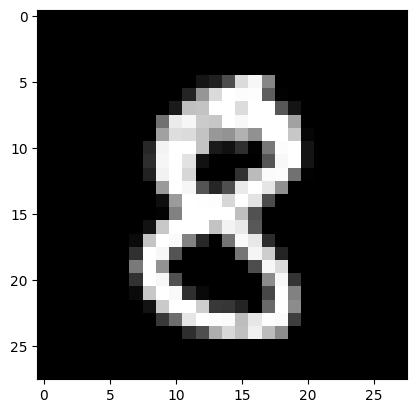

In [2]:
# MNIST
download = False
dataset_class = datasets.MNIST
mnist_transform = [transforms.ToTensor()]
mnist_transform.append(transforms.Normalize((0.1307,), (0.3081,)))
dataset_transform = transforms.Compose(mnist_transform)
mnist_train = dataset_class('./datasets/MNIST', train=True, download=download, transform=dataset_transform)
mnist_test = dataset_class('./datasets/MNIST', train=False, download=download, transform=dataset_transform)

# create a dataloader with batch size 1
mnist_train_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=1, shuffle=True)

# test the dataloader
for i, (data, target) in enumerate(mnist_train_loader):
    print(data.shape, target)
    # display the first image
    plt.imshow(data[0, 0].numpy(), cmap='gray')
    plt.show()
    break

seed = 1
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# randonly shuffle the training data
mnist_train_loader = DataLoader(mnist_train, batch_size=1, shuffle=True)

In [3]:
# use SVM to classify the data
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# train the SVM
X_train = []
y_train = []

for i, (data, target) in enumerate(mnist_train_loader):
    X_train.append(data[0].numpy().flatten())
    y_train.append(target.item())

X_train = np.array(X_train)
y_train = np.array(y_train)

clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

# test the SVM
X_test = []
y_test = []

for i, (data, target) in enumerate(mnist_test_loader):
    X_test.append(data[0].numpy().flatten())
    y_test.append(target.item())

X_test = np.array(X_test)
y_test = np.array(y_test)

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'SVM accuracy: {accuracy}')

KeyboardInterrupt: 

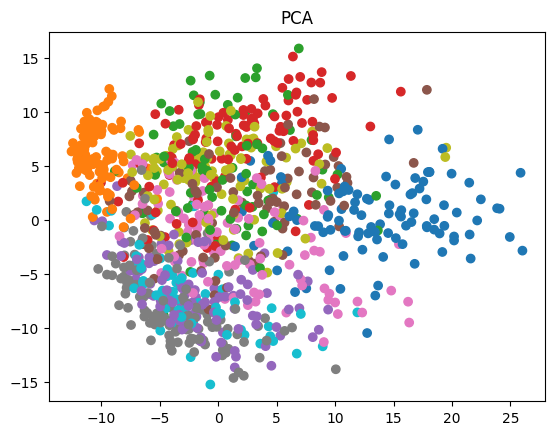

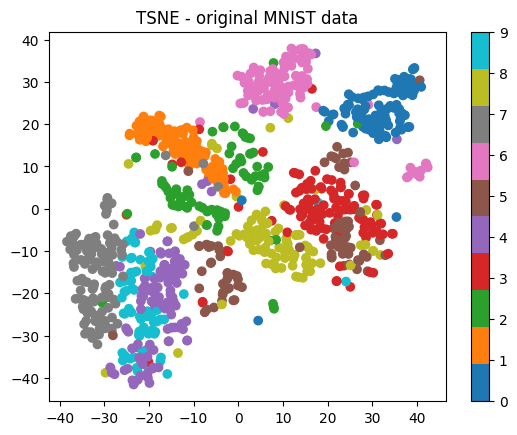

In [3]:
# tsne the data, with label as color
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

img_data = []
img_label = []
for i, (data, target) in enumerate(mnist_train_loader):
    # one hot the labels
    # label_one_hot = np.zeros(10)
    # label_one_hot[target.item()] = 1
    data = data.view(-1).numpy()
    # data = np.concatenate([data, label_one_hot])
    img_data.append(data)
    # img_data.append(data.view(-1).numpy())
    img_label.append(target.item())

# for i, (data, target) in enumerate(mnist_train_loader):
#     X.append(data[0].numpy().reshape(-1))
#     y.append(target.item())

X = np.array(img_data)[:1000]
y = np.array(img_label)[:1000]

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30)
X_pca = pca.fit_transform(X)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10')
plt.title('PCA')
plt.show()


plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
plt.title('TSNE - original MNIST data')
# add the legend
plt.colorbar()
plt.show()




In [23]:
def patchify(image, kernel_size=3, stride=1):
    patches = []
    for i in range(0, image.shape[0] - kernel_size + 1, stride):
        for j in range(0, image.shape[1] - kernel_size + 1, stride):
            patch = image[i:i + kernel_size, j:j + kernel_size]
            patches.append(patch)
    return np.array(patches)

In [5]:
embedding_dim = 28 * 28
tree = CobwebContinuousTree(size=embedding_dim, label_size=10,  max_num_instances=len(mnist_train) * 2, 
                            embed_size=embedding_dim,
                            learning_rate=1,
                            covar_type = 1,
                            covar_from = 2,
                            learn_embedding=False, use_onehot=False)

for i, (data, target) in enumerate(tqdm(mnist_train_loader)):
    # patches = patchify(data[0].numpy().reshape(28, 28), kernel_size=3, stride=1)
    data = data.view(-1).numpy()
    target = target.numpy()
    # hard code the label by appending the target to the data
    # target_one_hot = np.zeros(10)
    # target_one_hot[target.item()] = 1
    # data = np.append(data, target_one_hot)
    tree.ifit(data, target)
    # print(patches[0].shape)
    # break
    # if i > 1000:
    #     break
    # for patch in patches:
    #     tree.ifit(patch.flatten(), 1)

  0%|          | 0/60000 [00:00<?, ?it/s]/tmp/ipykernel_1934153/1333411350.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  tree.ifit(data, target)
100%|██████████| 60000/60000 [00:31<00:00, 1901.72it/s]


In [11]:
img_data[0].shape

(794,)

In [6]:
hidden_dim_l1 = 5000
# embedding_layer1 = tree.get_embedding_matrix()
w_l1, b_l1 = tree.get_weights_and_bias(hidden_dim_l1)
# count number of zeros
print(np.sum(b_l1 == 0))
# number of non-zero weights
print(np.sum(b_l1 != 0))
# print(w_l1)
# take the last 5000 w and b
# w_l1 = w_l1[10:]
# b_l1 = b_l1[10:]

# embedding_layer1 = torch.tensor(embedding_layer1)
img_data = torch.tensor(img_data, dtype=torch.float32)
# print(embedding_layer1.shape, img_data.shape)
w_l1 = torch.tensor(w_l1, dtype=torch.float32)
b_l1 = torch.tensor(b_l1, dtype=torch.float32)

# print(w_l1.shape, b_l1.shape)

out_layer1 = torch.matmul(img_data, w_l1.T) + b_l1
# use relu activation function
out_layer1 = torch.relu(out_layer1)
# # remove the zero weights
# out_layer1 = out_layer1[:, b_l1 != 0]
# sigmoid activation function
# out_layer1 = torch.sigmoid(out_layer1)
# print(out_layer1.shape)
out_layer1 = out_layer1.detach().numpy()

0
5000


/tmp/ipykernel_1934153/1130842222.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:274.)
  img_data = torch.tensor(img_data, dtype=torch.float32)


In [14]:
# count how many zeros in w and b 
num_zeros = np.sum(out_layer1[0] == 0)
print(num_zeros, len(out_layer1[0]), np.sum(out_layer1[0] != 0), np.log2(len(out_layer1[0])))

31099 59998 28899 15.872626789634394


In [7]:
tree_l2 = CobwebContinuousTree(size=hidden_dim_l1, label_size=10,  max_num_instances=60000, 
                            embed_size=hidden_dim_l1,
                            learning_rate=1,
                            covar_type = 1,
                            covar_from = 2,
                            learn_embedding=False, use_onehot=False)

# cast the output of the first layer to numpy
# out_layer1 = out_layer1.detach().numpy()

# tree_l2.set_embedding_matrix(out_layer1)

for img_rep in tqdm(out_layer1):
    # print(img_rep.shape)
    # break
    tree_l2.ifit(img_rep, 1)

  0%|          | 0/60000 [00:00<?, ?it/s]

100%|██████████| 60000/60000 [00:06<00:00, 8846.98it/s] 


In [19]:
hidden_dim_l2 = 500
w_l2, b_l2 = tree_l2.get_weights_and_bias(hidden_dim_l2)

out_layer1 = torch.tensor(out_layer1)
w_l2 = torch.tensor(w_l2)
b_l2 = torch.tensor(b_l2)

out_layer2 = torch.matmul(out_layer1, w_l2.T) + b_l2
out_layer2 = torch.relu(out_layer2)
out_layer2.shape

# test the second layer
test_rep_l1 = torch.matmul(torch.tensor(X_test), w_l1.T) + b_l1
test_rep_l1 = torch.relu(test_rep_l1)


NameError: name 'tree_l2' is not defined

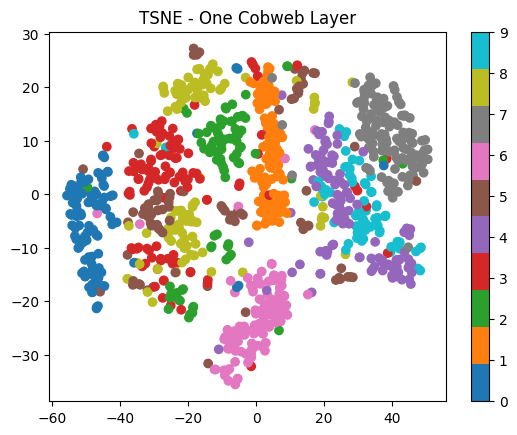

In [7]:
X = np.array(out_layer1)[:1000]
y = np.array(img_label)[:1000]

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30)
X_pca = pca.fit_transform(X)
X_tsne = tsne.fit_transform(X)

# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10')
# plt.title('PCA')
# plt.show()


plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
plt.title('TSNE - One Cobweb Layer')
# add the legend
plt.colorbar()
plt.show()

# # test the SVM
# clf = SVC(kernel='linear')
# clf.fit(out_layer1, y_train)

# # test the SVM
# y_pred = clf.predict(test_rep_l1)
# accuracy = accuracy_score(y_test, y_pred)
# print(f'SVM accuracy at layer 1: {accuracy}')



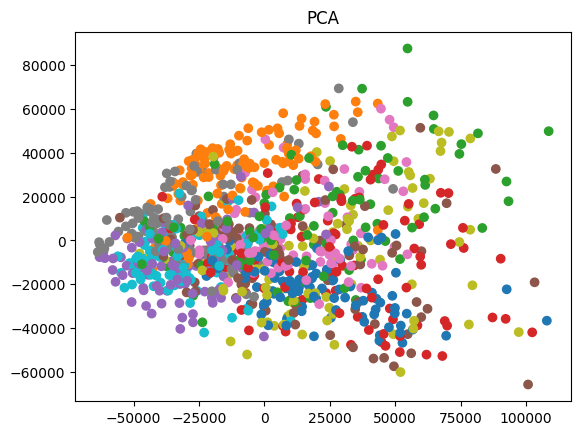

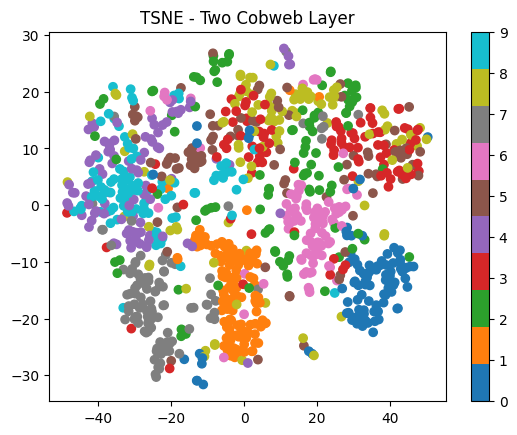

In [10]:
X = np.array(out_layer2)[:1000]
y = np.array(img_label)[:1000]

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=30)
X_pca = pca.fit_transform(X)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10')
plt.title('PCA')
plt.show()


plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
plt.title('TSNE - Two Cobweb Layer')
# add the legend
plt.colorbar()
plt.show()

# Multiplayer COBWEB

In [9]:
layers = 5
hidden_dim_l = 28 * 28

in_data = img_data

hidden_reps = []

for l in range(layers):
    tree_l = CobwebContinuousTree(size=hidden_dim_l, label_size=10,  max_num_instances=60000, 
                            embed_size=hidden_dim_l,
                            learning_rate=1,
                            covar_type = 1,
                            covar_from = 2,
                            learn_embedding=False, use_onehot=False)
    
    for i, data in enumerate(tqdm(in_data)):
    # patches = patchify(data[0].numpy().reshape(28, 28), kernel_size=3, stride=1)
        data = data.view(-1).numpy()
        # print(data.shape)
        # break
        tree_l.ifit(data, 1)

    hidden_dim_l = 600
        
    w_l, b_l = tree_l.get_weights_and_bias(hidden_dim_l)

    w_l = torch.tensor(w_l)
    b_l = torch.tensor(b_l)

    # w_l = -w_l

    out_layer = torch.matmul(in_data, w_l.T) + b_l
    # out_layer = torch.relu(out_layer)
    out_layer = torch.sigmoid(out_layer)
    # out_layer = out_layer.detach().numpy()

    in_data = out_layer
    print(out_layer.shape)
    print(in_data.shape)

    hidden_reps.append(out_layer)

  0%|          | 0/60000 [00:00<?, ?it/s]

100%|██████████| 60000/60000 [00:09<00:00, 6191.54it/s]


torch.Size([60000, 600])
torch.Size([60000, 600])


100%|██████████| 60000/60000 [00:09<00:00, 6318.91it/s]


torch.Size([60000, 600])
torch.Size([60000, 600])


...

torch.Size([60000, 600])
torch.Size([60000, 600])


100%|██████████| 60000/60000 [00:09<00:00, 6160.82it/s]


torch.Size([60000, 600])
torch.Size([60000, 600])


100%|██████████| 60000/60000 [00:09<00:00, 6067.30it/s]


torch.Size([60000, 600])
torch.Size([60000, 600])


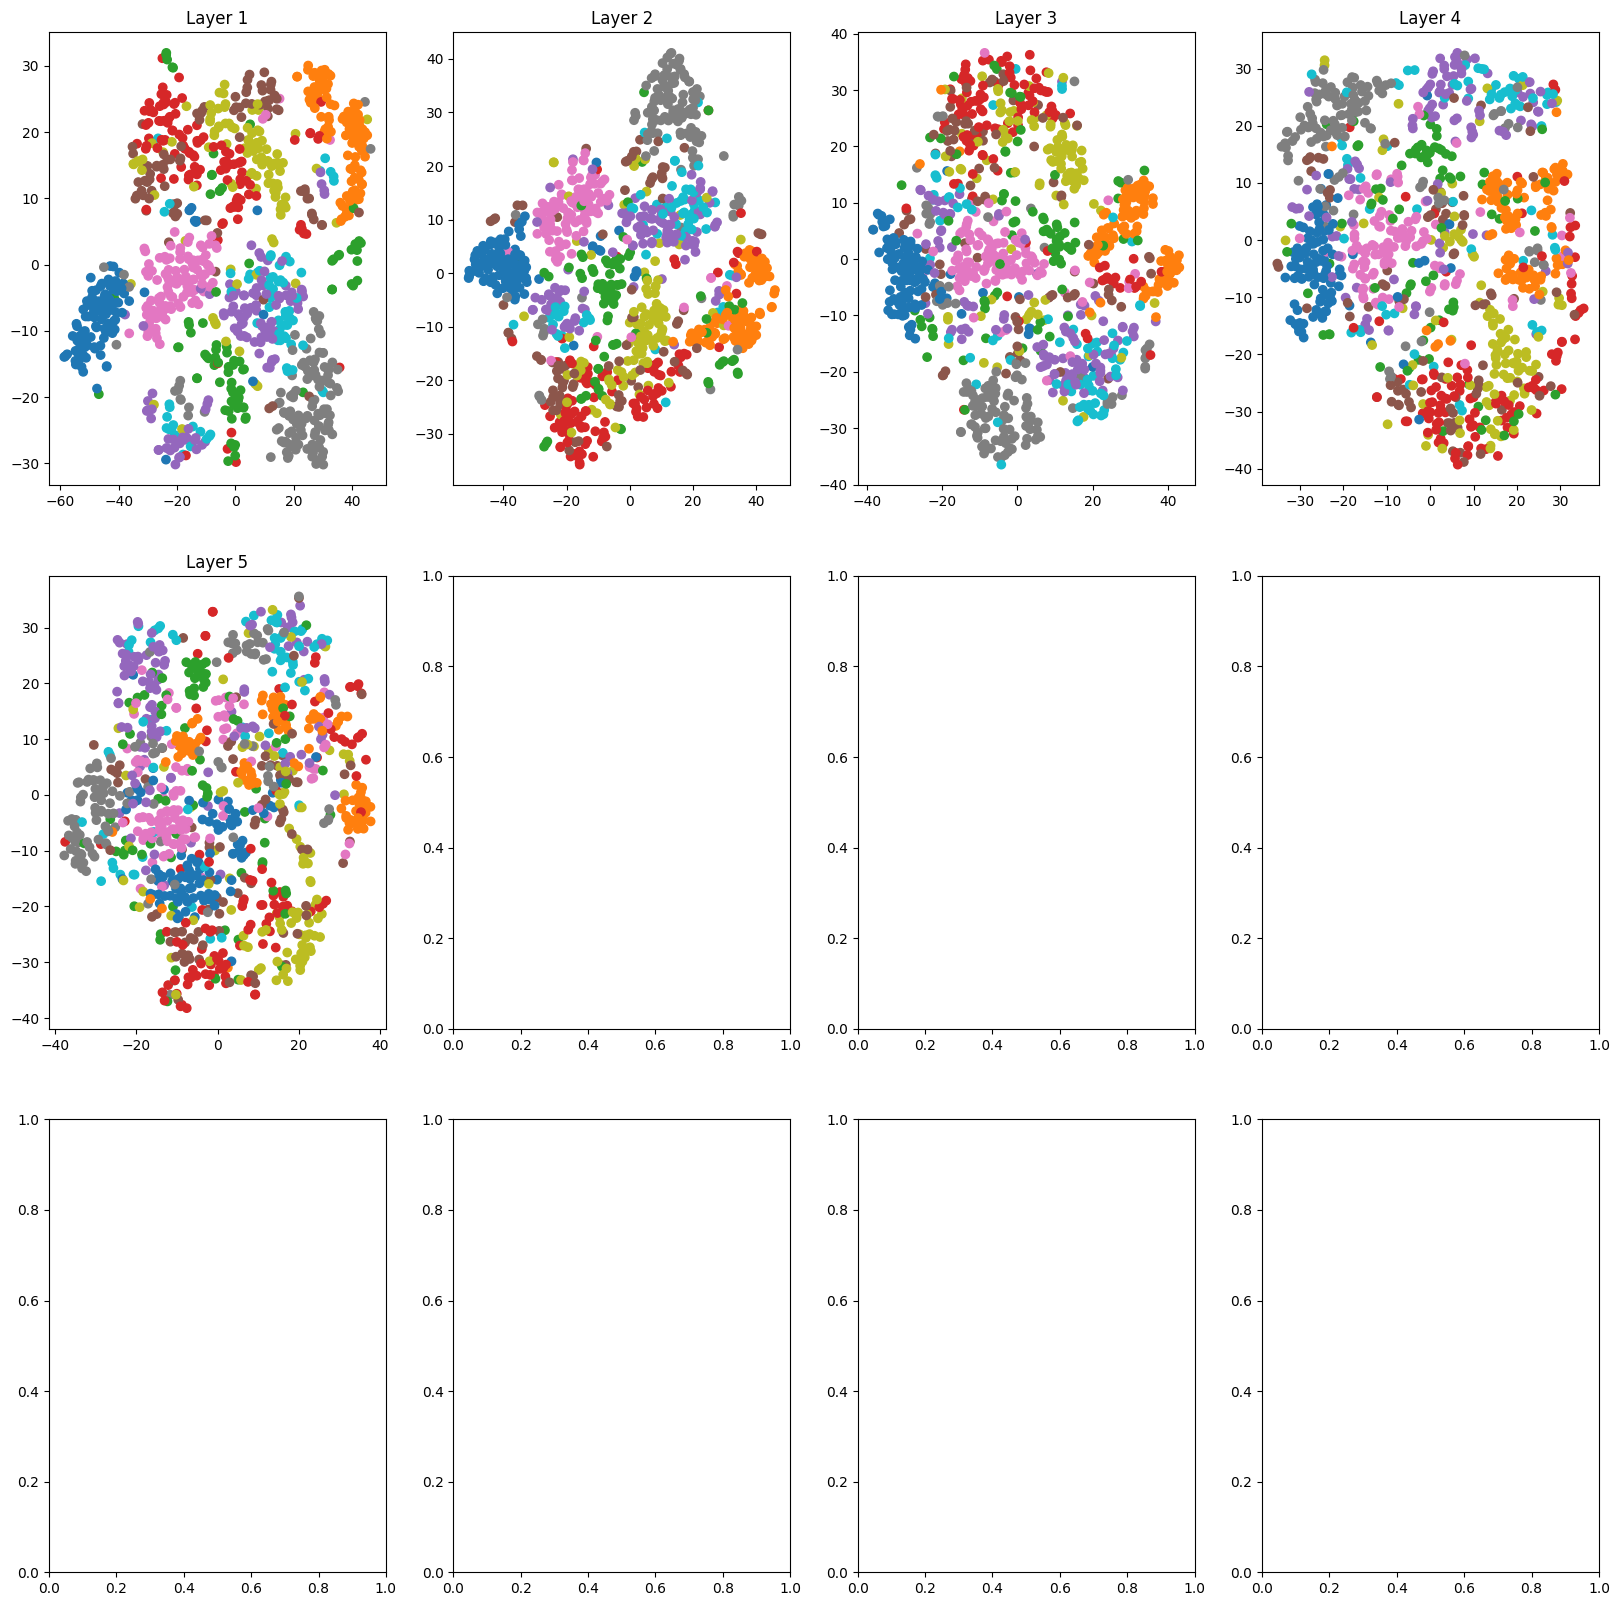

In [10]:
# create a subplots of 3 * 4
fig, axs = plt.subplots(3, 4, figsize=(20, 20))

for i, hidden_rep in enumerate(hidden_reps):
    X = np.array(hidden_rep)[:1000]
    y = np.array(img_label)[:1000]

    pca = PCA(n_components=2)
    tsne = TSNE(n_components=2, perplexity=30)
    X_pca = pca.fit_transform(X)
    X_tsne = tsne.fit_transform(X)

    ax = axs[i // 4, i % 4]
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
    ax.set_title(f'Layer {i + 1}')

## CNN

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Define CNN model
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def extract_features(self, x):
        # Extract features before the final classification layer
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x

In [7]:
# Step 2: Prepare Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# Step 3: Train the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on {device}")
model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 4

for epoch in range(num_epochs):
    model.train()
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Training complete.")

Training on cuda


  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 938/938 [00:10<00:00, 89.74it/s]


Epoch [1/4], Loss: 0.1271


100%|██████████| 938/938 [00:09<00:00, 93.83it/s]


Epoch [2/4], Loss: 0.0385


100%|██████████| 938/938 [00:10<00:00, 93.74it/s]


Epoch [3/4], Loss: 0.0022


100%|██████████| 938/938 [00:09<00:00, 93.86it/s]

Epoch [4/4], Loss: 0.0223
Training complete.


  0%|          | 0/10 [00:00<?, ?it/s]


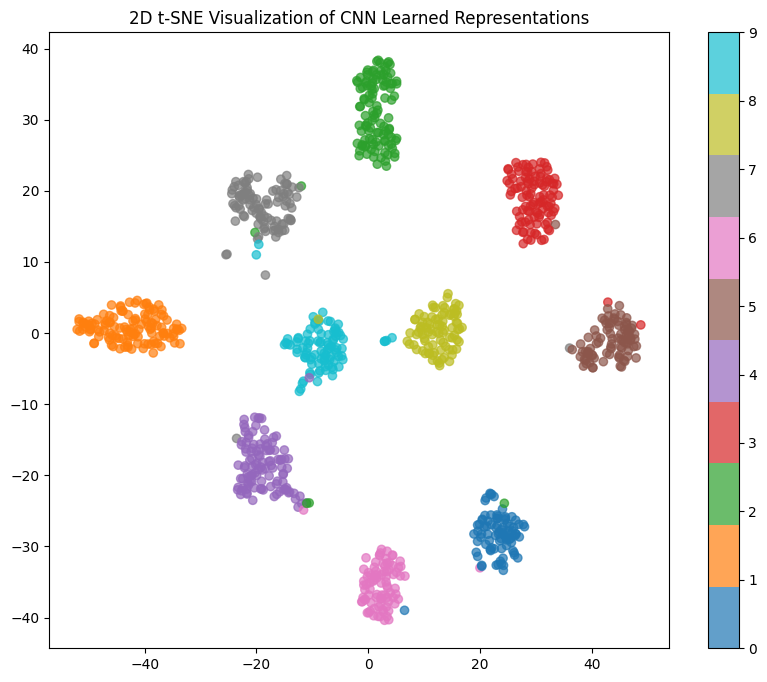

In [8]:
# Step 4: Extract features from test set and apply t-SNE
model.eval()
all_features = []
all_labels = []

with torch.no_grad():
    for i, (images, labels) in enumerate(tqdm(test_loader)):
        images = images.to(device)
        features = model.extract_features(images)
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())
        if i == 0:
            break

# Concatenate all features and labels
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Step 5: Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced_features = tsne.fit_transform(all_features)

# Plot the 2D representation
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter)
plt.title("2D t-SNE Visualization of CNN Learned Representations")
plt.show()

In [13]:
# svm on the CNN features
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# train the SVM
clf = SVC(kernel='linear')
clf.fit(all_features, all_labels)

# test the SVM
all_features_test = []
all_labels_test = []

with torch.no_grad():
    for i, (images, labels) in enumerate(tqdm(test_loader)):
        images = images.to(device)
        features = model.extract_features(images)
        all_features_test.append(features.cpu().numpy())
        all_labels_test.append(labels.numpy())

# Concatenate all features and labels
all_features_test = np.concatenate(all_features_test, axis=0)
all_labels_test = np.concatenate(all_labels_test, axis=0)

y_pred = clf.predict(all_features_test)
accuracy = accuracy_score(all_labels_test, y_pred)
print(f'SVM accuracy on CNN features: {accuracy}')

100%|██████████| 10/10 [00:01<00:00,  6.87it/s]

SVM accuracy on CNN features: 0.9866


## FC

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Fully Connected Network Definition (No Convolution)
class FullyConnectedModel(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=128, num_classes=10):
        super(FullyConnectedModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the image
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def extract_features(self, x):
        x = x.view(x.size(0), -1)  # Flatten the image
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return x

In [15]:
# Step 2: Prepare Data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# Step 3: Train the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FullyConnectedModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 4

for epoch in range(num_epochs):
    model.train()
    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("Training complete.")

  0%|          | 0/938 [00:00<?, ?it/s]

100%|██████████| 938/938 [00:09<00:00, 97.59it/s]


Epoch [1/4], Loss: 0.1762


100%|██████████| 938/938 [00:09<00:00, 97.37it/s]


Epoch [2/4], Loss: 0.1596


100%|██████████| 938/938 [00:09<00:00, 97.93it/s]


Epoch [3/4], Loss: 0.1413


100%|██████████| 938/938 [00:09<00:00, 97.49it/s]

Epoch [4/4], Loss: 0.0187
Training complete.


  0%|          | 0/10 [00:00<?, ?it/s]


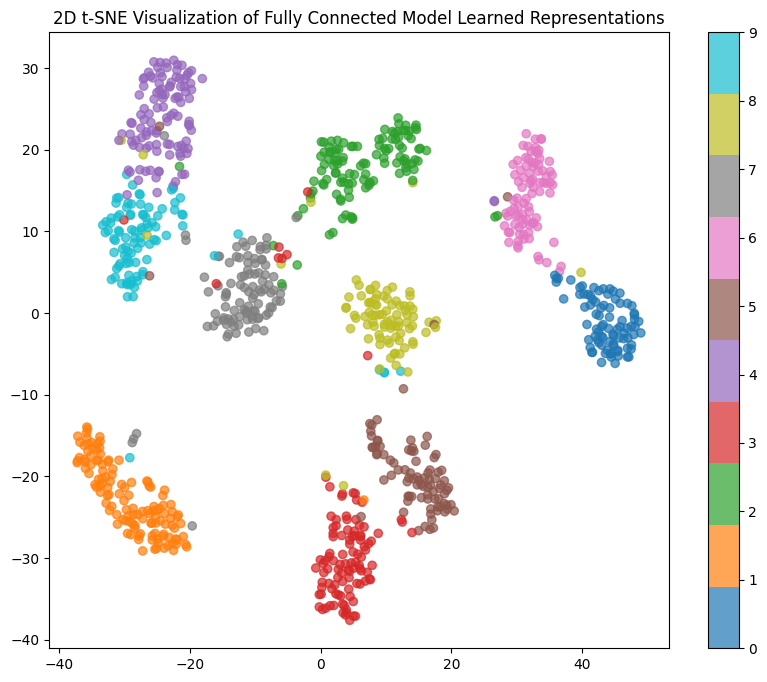

In [16]:
# Step 4: Extract features from test set and apply t-SNE
model.eval()
all_features = []
all_labels = []

with torch.no_grad():
    for i, (images, labels) in enumerate(tqdm(test_loader)):
        images = images.to(device)
        features = model.extract_features(images)
        all_features.append(features.cpu().numpy())
        all_labels.append(labels.numpy())
        if i == 0:
            break

# Concatenate all features and labels
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Step 5: Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced_features = tsne.fit_transform(all_features)

# Plot the 2D representation
plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter)
plt.title("2D t-SNE Visualization of Fully Connected Model Learned Representations")
plt.show()